In [1]:
import os
import glob
import numpy as np
import pandas as pd
import nibabel as nib

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, confusion_matrix
)


In [2]:
LABEL_CSV = r"D:\Similiar_Colorectum\14004841\case_labels_binary.csv"
df_labels = pd.read_csv(LABEL_CSV)

case_to_label = dict(
    zip(df_labels.case_id, df_labels.label_binary)
)

print("Total patients:", len(case_to_label))


Total patients: 116


In [3]:
def get_tumor_slices(ct_path, mask_path):
    ct = nib.load(ct_path).get_fdata()
    mask = nib.load(mask_path).get_fdata()

    slices = []
    for z in range(ct.shape[2]):
        if np.any(mask[:, :, z] > 0):
            slices.append(ct[:, :, z])

    return slices


In [4]:
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
])

def preprocess_slice(slice_2d):
    slice_2d = np.clip(slice_2d, -200, 200)
    slice_2d = (slice_2d - slice_2d.min()) / (slice_2d.max() + 1e-6)
    slice_2d = (slice_2d * 255).astype(np.uint8)
    slice_2d = np.stack([slice_2d]*3, axis=-1)
    return transform(slice_2d)


In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

resnet = models.resnet18(pretrained=True)
resnet.fc = nn.Identity()
resnet = resnet.to(device).eval()


c:\Users\100ra\anaconda3\envs\ram_env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\100ra\anaconda3\envs\ram_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [6]:
@torch.no_grad()
def extract_slice_features(slices):
    feats = []
    for sl in slices:
        x = preprocess_slice(sl).unsqueeze(0).to(device)
        f = resnet(x).cpu().numpy().squeeze()
        feats.append(f)
    return np.array(feats)


In [7]:
def mil_topk(features, k=5):
    norms = np.linalg.norm(features, axis=1)
    topk_idx = np.argsort(norms)[-k:]
    return features[topk_idx].mean(axis=0)


In [8]:
def mil_weighted(features):
    weights = np.linalg.norm(features, axis=1)
    weights = weights / (weights.sum() + 1e-6)
    return (features * weights[:, None]).sum(axis=0)


## Branch-3: Augmented Top-K MIL

In [9]:
def augment_slice(slice_2d):
    noise = np.random.normal(0, 0.02, slice_2d.shape)
    return slice_2d + noise

def mil_augmented_topk(slices, k=5):
    feats = extract_slice_features(slices)
    norms = np.linalg.norm(feats, axis=1)
    topk_idx = np.argsort(norms)[-k:]

    aug_slices = [augment_slice(slices[i]) for i in topk_idx]
    aug_feats = extract_slice_features(aug_slices)

    return aug_feats.mean(axis=0)


In [10]:
case_ids = []
X_topk, X_weighted, X_aug, y = [], [], [], []


IMG_DIR = r"D:\Similiar_Colorectum\14004841\images\images"
MASK_DIR = r"D:\Similiar_Colorectum\14004841\lms\lms"

for case_id, label in case_to_label.items():
    ct = glob.glob(f"{IMG_DIR}/crc_{case_id}_*.nii.gz")
    mk = glob.glob(f"{MASK_DIR}/crc_{case_id}_*.nii.gz")

    if len(ct) == 0 or len(mk) == 0:
        continue

    slices = get_tumor_slices(ct[0], mk[0])
    feats = extract_slice_features(slices)

    X_topk.append(mil_topk(feats))
    X_weighted.append(mil_weighted(feats))
    X_aug.append(mil_augmented_topk(slices))

    y.append(label)
    case_ids.append(case_id)

X_topk = np.array(X_topk)
X_weighted = np.array(X_weighted)
X_aug = np.array(X_aug)
y = np.array(y)

print(X_topk.shape, X_weighted.shape, X_aug.shape)


(116, 512) (116, 512) (116, 512)


In [11]:
def save_mil_csv(X, y, case_ids, out_path):
    df = pd.DataFrame(X)
    df.insert(0, "case_id", case_ids)
    df["label"] = y
    df.to_csv(out_path, index=False)
    print(f"Saved: {out_path}")

BASE_OUT = r"D:\Similiar_Colorectum\14004841"

save_mil_csv(
    X_topk, y, case_ids,
    os.path.join(BASE_OUT, "mil_topk_features.csv")
)

save_mil_csv(
    X_weighted, y, case_ids,
    os.path.join(BASE_OUT, "mil_weighted_features.csv")
)

save_mil_csv(
    X_aug, y, case_ids,
    os.path.join(BASE_OUT, "mil_augmented_features.csv")
)


Saved: D:\Similiar_Colorectum\14004841\mil_topk_features.csv
Saved: D:\Similiar_Colorectum\14004841\mil_weighted_features.csv
Saved: D:\Similiar_Colorectum\14004841\mil_augmented_features.csv


===============================
## SECTION 4: CLASSIFIERS
===============================

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

models = {
    "Logistic": LogisticRegression(class_weight="balanced", max_iter=1000),
    "Linear SVM": SVC(kernel="linear", class_weight="balanced", probability=True),
    "RBF SVM": SVC(kernel="rbf", class_weight="balanced", probability=True),
    "RF": RandomForestClassifier(n_estimators=200, class_weight="balanced"),
    "GB": GradientBoostingClassifier(),
    "kNN": KNeighborsClassifier(7),
    "NB": GaussianNB(),
    "LDA": LinearDiscriminantAnalysis()
}


In [13]:
def evaluate_models_kfold(X, y, branch_name):
    rows = []
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for name, model in models.items():
        for fold, (tr, te) in enumerate(skf.split(X, y), start=1):

            scaler = StandardScaler()
            Xtr = scaler.fit_transform(X[tr])
            Xte = scaler.transform(X[te])

            model.fit(Xtr, y[tr])
            pred = model.predict(Xte)

            rows.append({
                "Branch": branch_name,
                "Model": name,
                "Fold": fold,
                "Accuracy": accuracy_score(y[te], pred),
                "Recall_1": recall_score(y[te], pred),
                "Macro_F1": f1_score(y[te], pred, average="macro")
            })

    return pd.DataFrame(rows)


In [14]:
df_topk = evaluate_models_kfold(X_topk, y, "Top-K")
df_weighted = evaluate_models_kfold(X_weighted, y, "Weighted")
df_aug = evaluate_models_kfold(X_aug, y, "Augmented")

all_kfold_df = pd.concat([df_topk, df_weighted, df_aug], ignore_index=True)

display(all_kfold_df.head())


c:\Users\100ra\anaconda3\envs\ram_env\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\100ra\anaconda3\envs\ram_env\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\100ra\anaconda3\envs\ram_env\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\100ra\anaconda3\envs\ram_env\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\100ra\anaconda3\envs\ram_env\Lib\subprocess.py", line

,Branch,Model,Fold,Accuracy,Recall_1,Macro_F1
0,Top-K,Logistic,1,0.583333,0.500000,0.531250
1,Top-K,Logistic,2,0.652174,0.666667,0.616667
2,Top-K,Logistic,3,0.695652,0.000000,0.410256
3,Top-K,Logistic,4,0.608696,0.166667,0.462338
4,Top-K,Logistic,5,0.695652,0.166667,0.516517


In [15]:
summary_df = (
    all_kfold_df
    .groupby(["Branch", "Model"])
    .agg(
        Accuracy_mean=("Accuracy", "mean"),
        Accuracy_std=("Accuracy", "std"),
        Recall1_mean=("Recall_1", "mean"),
        Recall1_std=("Recall_1", "std"),
        MacroF1_mean=("Macro_F1", "mean"),
        MacroF1_std=("Macro_F1", "std"),
    )
    .reset_index()
)

display(summary_df)


,Branch,Model,Accuracy_mean,Accuracy_std,Recall1_mean,Recall1_std,MacroF1_mean,MacroF1_std
0,Augmented,GB,0.655072,0.031420,0.200000,0.139443,0.494636,0.060673
1,Augmented,LDA,0.603261,0.084371,0.500000,0.263523,0.536745,0.076331
2,Augmented,Linear SVM,0.638406,0.068764,0.300000,0.273861,0.504996,0.089058
3,Augmented,Logistic,0.655797,0.063276,0.300000,0.273861,0.513313,0.079522
4,Augmented,NB,0.587319,0.080615,0.233333,0.190029,0.460533,0.086372
5,Augmented,RBF SVM,0.690942,0.100764,0.233333,0.190029,0.534976,0.135033
6,Augmented,RF,0.758696,0.022276,0.066667,0.091287,0.487216,0.083576
7,Augmented,kNN,0.741667,0.026489,0.033333,0.074536,0.453678,0.070064
8,Top-K,GB,0.680797,0.026637,0.166667,0.166667,0.495006,0.095670
9,Top-K,LDA,0.672464,0.021979,0.366667,0.273861,0.554506,0.048436


In [25]:
df_topk_feat = pd.read_csv(
    r"D:\Similiar_Colorectum\14004841\mil_topk_features.csv"
)

df_weighted_feat = pd.read_csv(
    r"D:\Similiar_Colorectum\14004841\mil_weighted_features.csv"
)

df_aug_feat = pd.read_csv(
    r"D:\Similiar_Colorectum\14004841\mil_augmented_features.csv"
)


In [29]:
LABEL_COL = "label"

branches = {
    "Top-K": df_topk_feat,
    "Weighted": df_weighted_feat,
    "Augmented": df_aug_feat
}


In [30]:
best_models = (
    summary_df
    .sort_values(
        by=["Recall1_mean", "MacroF1_mean", "Accuracy_mean"],
        ascending=False
    )
    .groupby("Branch")
    .head(1)
)

best_models


,Branch,Model,Accuracy_mean,Accuracy_std,Recall1_mean,Recall1_std,MacroF1_mean,MacroF1_std
20,Weighted,NB,0.681522,0.044085,0.566667,0.190029,0.619152,0.043997
1,Augmented,LDA,0.603261,0.084371,0.500000,0.263523,0.536745,0.076331
9,Top-K,LDA,0.672464,0.021979,0.366667,0.273861,0.554506,0.048436


In [31]:
final_models = {}

for _, row in best_models.iterrows():
    branch = row["Branch"]        # e.g. "Top-K"
    model_name = row["Model"]     # e.g. "Linear SVM"

    df_feat = branches[branch]   # ✅ feature dataframe

    X = df_feat.drop(
        columns=["case_id", LABEL_COL],
        errors="ignore"
    ).values

    y = df_feat[LABEL_COL].values

    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    model = models[model_name]
    model.fit(Xs, y)

    final_models[branch] = {
        "model": model,
        "scaler": scaler
    }


In [32]:
print(df.columns.tolist())


['Branch', 'Model', 'Fold', 'Accuracy', 'Recall_1', 'Macro_F1']


In [33]:
def majority_vote(preds):
    return int(np.round(np.mean(preds)))


In [39]:
skf = StratifiedKFold(5, shuffle=True, random_state=42)

y_true_all, y_vote_all = [], []

for tr, va in skf.split(X, y):

    vote_preds = []   # will store [n_branches, n_samples]

    for branch, df in branches.items():

        # Remove non-feature columns
        Xb = df.drop(columns=["case_id", "label"], errors="ignore").values
        yb = df["label"].values

        scaler = StandardScaler()
        Xtr = scaler.fit_transform(Xb[tr])
        Xva = scaler.transform(Xb[va])

        model_name = (
            best_models[best_models["Branch"] == branch]["Model"].values[0]
        )
        model = models[model_name]

        model.fit(Xtr, yb[tr])
        vote_preds.append(model.predict(Xva))   # HARD predictions only

    # Shape: (n_branches, n_samples)
    vote_preds = np.array(vote_preds)

    # Majority voting per sample
    y_vote = np.apply_along_axis(
        majority_vote,
        axis=0,
        arr=vote_preds
    )

    y_true_all.extend(y[va])
    y_vote_all.extend(y_vote)


In [40]:
from sklearn.metrics import classification_report, confusion_matrix

print("FINAL VOTING PERFORMANCE")
print("Accuracy:", accuracy_score(y_true_all, y_vote_all))
print("Recall (Malignant):", recall_score(y_true_all, y_vote_all))
print("Macro F1:", f1_score(y_true_all, y_vote_all, average="macro"))

print("\nDetailed Report:")
print(classification_report(y_true_all, y_vote_all))


FINAL VOTING PERFORMANCE
Accuracy: 0.6724137931034483
Recall (Malignant): 0.4666666666666667
Macro F1: 0.597663380795911

Detailed Report:
              precision    recall  f1-score   support

           0       0.80      0.74      0.77        86
           1       0.39      0.47      0.42        30

    accuracy                           0.67       116
   macro avg       0.59      0.61      0.60       116
weighted avg       0.69      0.67      0.68       116



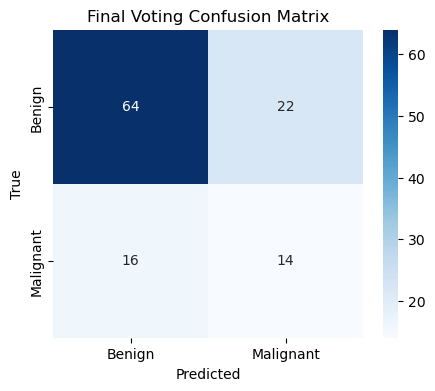

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_all, y_vote_all)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Final Voting Confusion Matrix")
plt.show()
